<a href="https://colab.research.google.com/github/estebanszd/Clases_Introduccion_CC/blob/main/Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRIMERO IMPORTAMOS NUESTRAS HERRAMIENTAS PRINCIPALES


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Para crear nuestro Data Frame con datos ficticios usamos el **pd.DataFrame** y añadimos las columnas que necesitamos, en este caso las que queremos como base y que se creen al azar utilizamos el **np.random.choice y np.random.normal**


In [103]:
np.random.seed(45)
n_clientes = 1000
df_hr = pd.DataFrame({
    'ID_cliente': range(1, n_clientes + 1),
    'Edad': np.random.normal(34, 8, n_clientes).clip(18, 70).astype(int),
    'Nivel_Educativo': np.random.choice(["Ninguna","Bachiller", "Profesional", "Maestría", "Doctorado", "Tecnico"], n_clientes, p=[0.05, 0.35, 0.2, 0.15, 0.05, 0.2 ])
})


Nos hacen falta aún dos variables en el data frame pero que no pueden ser escogidas tan al azar ya que deben ser basadas en variables ya existentes para tener coherencia, en este caso el salario mensual lo vamos a basar en el nivel de educación ya que a mayor nivel de educación, mayores serían los ingresos (En teoría).
Creamos la variable salario mensual y por educación vamos dando un valor y creamnos la variable en **df_hr["Salario_Mensual(USD)"]**, usamos el nivel educativo y el **map** para que se le añada el valor por nivel de educación, usamos el **np.random.normal** para que haya una variación en los ingresos y no sea un simple número estático


In [104]:
salario_mensual= {"Ninguna":1500,"Bachiller": 3000, "Profesional": 6500, "Maestría": 8500, "Doctorado": 11000, "Tecnico": 4500}
df_hr["Salario_Mensual(USD)"] = df_hr["Nivel_Educativo"].map(salario_mensual) + np.random.normal(0, 500, n_clientes)
df_hr["Salario_Mensual(USD)"] = df_hr["Salario_Mensual(USD)"].round(2)

In [105]:
df_hr.head()

,ID_cliente,Edad,Nivel_Educativo,Salario_Mensual(USD)
0,1,34,Maestría,9070.70
1,2,36,Tecnico,4344.71
2,3,30,Doctorado,11481.73
3,4,32,Doctorado,11174.63
4,5,23,Doctorado,9879.38


Para la aprobación del crédito haremos que exista una variable llamada **aprobación** basada en el salario mensual de los clientes donde si es menor a 4500 se le rechaza el crédito y si es mayor se le aprueba.
creamos la variable **Crédito_Aprobado** y usamos el **.map** y si es True validamos como si y si es false validamos como No

In [106]:
aprobacion =  df_hr['Salario_Mensual(USD)'] >= 4500
df_hr["Crédito_Aprobado"] =  aprobacion.map({True: 'Si', False: 'No'})

In [107]:
df_hr.head()

,ID_cliente,Edad,Nivel_Educativo,Salario_Mensual(USD),Crédito_Aprobado
0,1,34,Maestría,9070.70,Si
1,2,36,Tecnico,4344.71,No
2,3,30,Doctorado,11481.73,Si
3,4,32,Doctorado,11174.63,Si
4,5,23,Doctorado,9879.38,Si


Realizamos un histograma en este caso para evaluar el nivel educativo de los clientes, y cantidad de clientes con ese nivel de educación

Text(0, 0.5, 'Número de clientes')

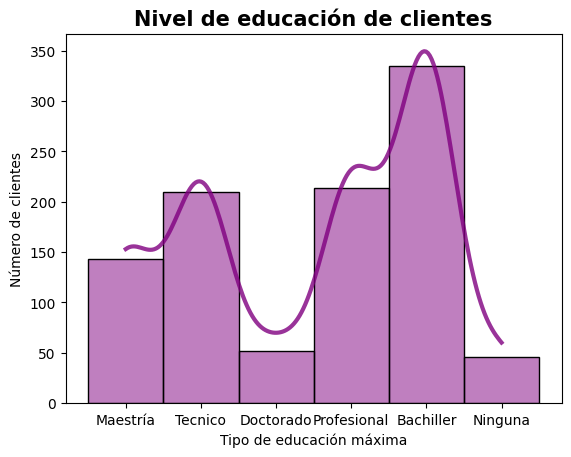

In [108]:
sns.histplot(df_hr["Nivel_Educativo"], bins=100, color="purple", kde=True,
             line_kws={"linewidth": 3, "color": "purple", "alpha": 0.8})
plt.title("Nivel de educación de clientes", fontsize=15, fontweight="bold")
plt.xlabel("Tipo de educación máxima")
plt.ylabel("Número de clientes")

En este caso queremos crear varios diagramas de cajas para representar los ingresos mensuales de los clientes en base a su nivel educativo, usasmos el **sns.boxplot** y lo evaluamos en X como nivel educativo y en Y como Ingresos, se mostrarán las gráficas individuales en un mismo recuadro

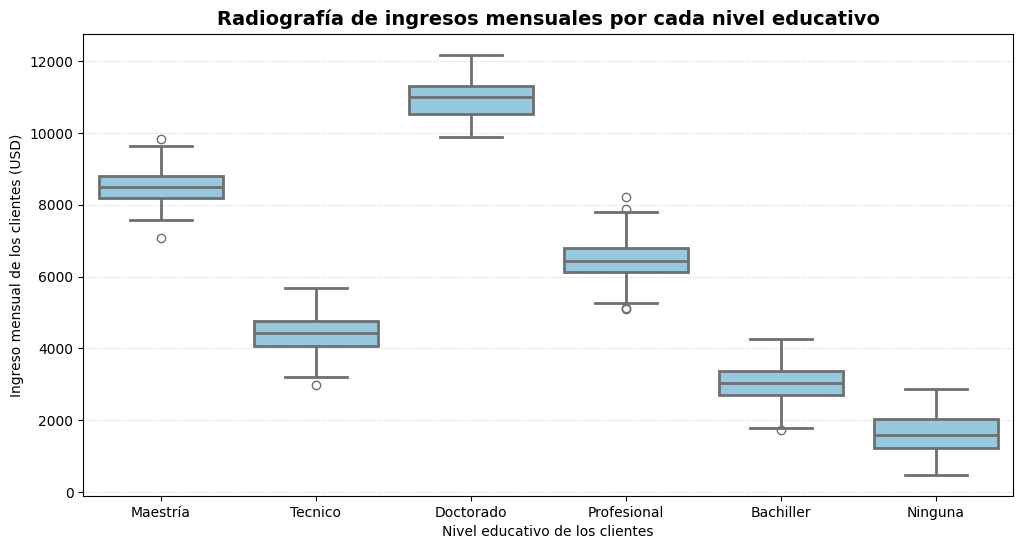

In [119]:
plt.figure(figsize=(12, 6))

sns.boxplot(x="Nivel_Educativo", y="Salario_Mensual(USD)", data=df_hr,
               color="skyblue",linewidth=2)

plt.title("Ingresos mensuales por cada nivel educativo", fontsize=14, fontweight="bold")
plt.ylabel("Ingreso mensual de los clientes (USD)")
plt.xlabel("Nivel educativo de los clientes")
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.show()

Realizamos un diagrama de dispersi+on en base a los mismos datos, edad e ingresos mensuales, marcamos el hue en el nivel educativo para que sea más clara la razón de su dispersión, se puede ver claramente como los puntos mas altos de ingreso son verdes ya que son el nivel de educación más alta

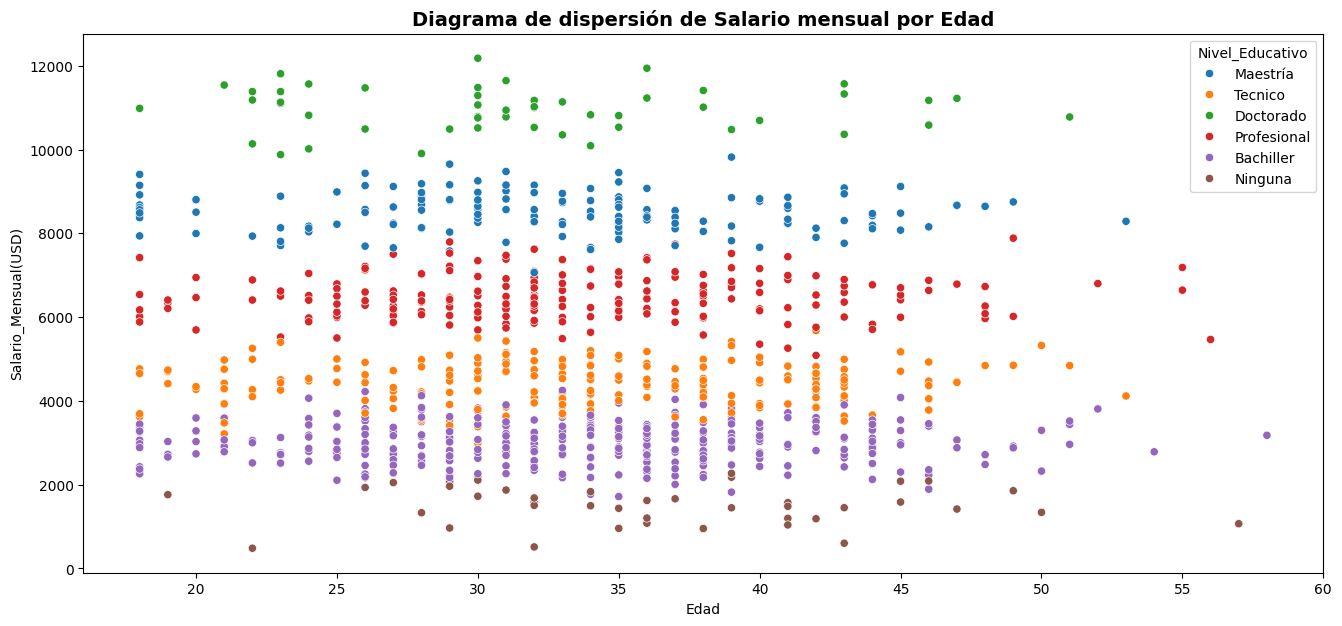

In [116]:
plt.figure(figsize=(16,7)) # Configura el tamaño de la figura
sns.scatterplot(data=df_hr, x='Edad', y='Salario_Mensual(USD)', hue = 'Nivel_Educativo' )
plt.title("Diagrama de dispersión de Salario mensual por Edad", fontsize=14, fontweight="bold")
plt.show()

Este diagrama es exactamente el mismo que se realizó arriba pero es interactivo y permite evaluar las variables individualmente o en grupos por su nivel educativo

In [111]:
import plotly.express as px
# Importa la librería Plotly Express para gráficos interactivos
#Creamos el mismo gráfico disperso pero añadiendo toda la data subyacente al pasar el cursor.
fig = px.scatter(df_hr, x='Edad', y='Salario_Mensual(USD)',
                 color='Nivel_Educativo',

                 hover_data=["ID_cliente", 'Edad', 'Salario_Mensual(USD)'], #Agrega esta info al popup
                 title="Explorador de Clientes Interactivo (Haz hover, clickea la leyenda o haz zoom)") # Crea un gráfico de dispersión interactivo
#Fig.update_layout(template="plotly_white")
fig.show()